In [1]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.cm as cm

In [2]:
def place_label_no_overlap(ax, x, y, text, placed_labels, min_sep=0.01, cut=0.07, font_size=16):
    while any(abs(x - px) < cut and abs(y - py) < min_sep for (px, py) in placed_labels):
        y += min_sep
    ax.text(x, y, text, ha='center', va='bottom', fontsize=font_size)
    placed_labels.append((x, y))

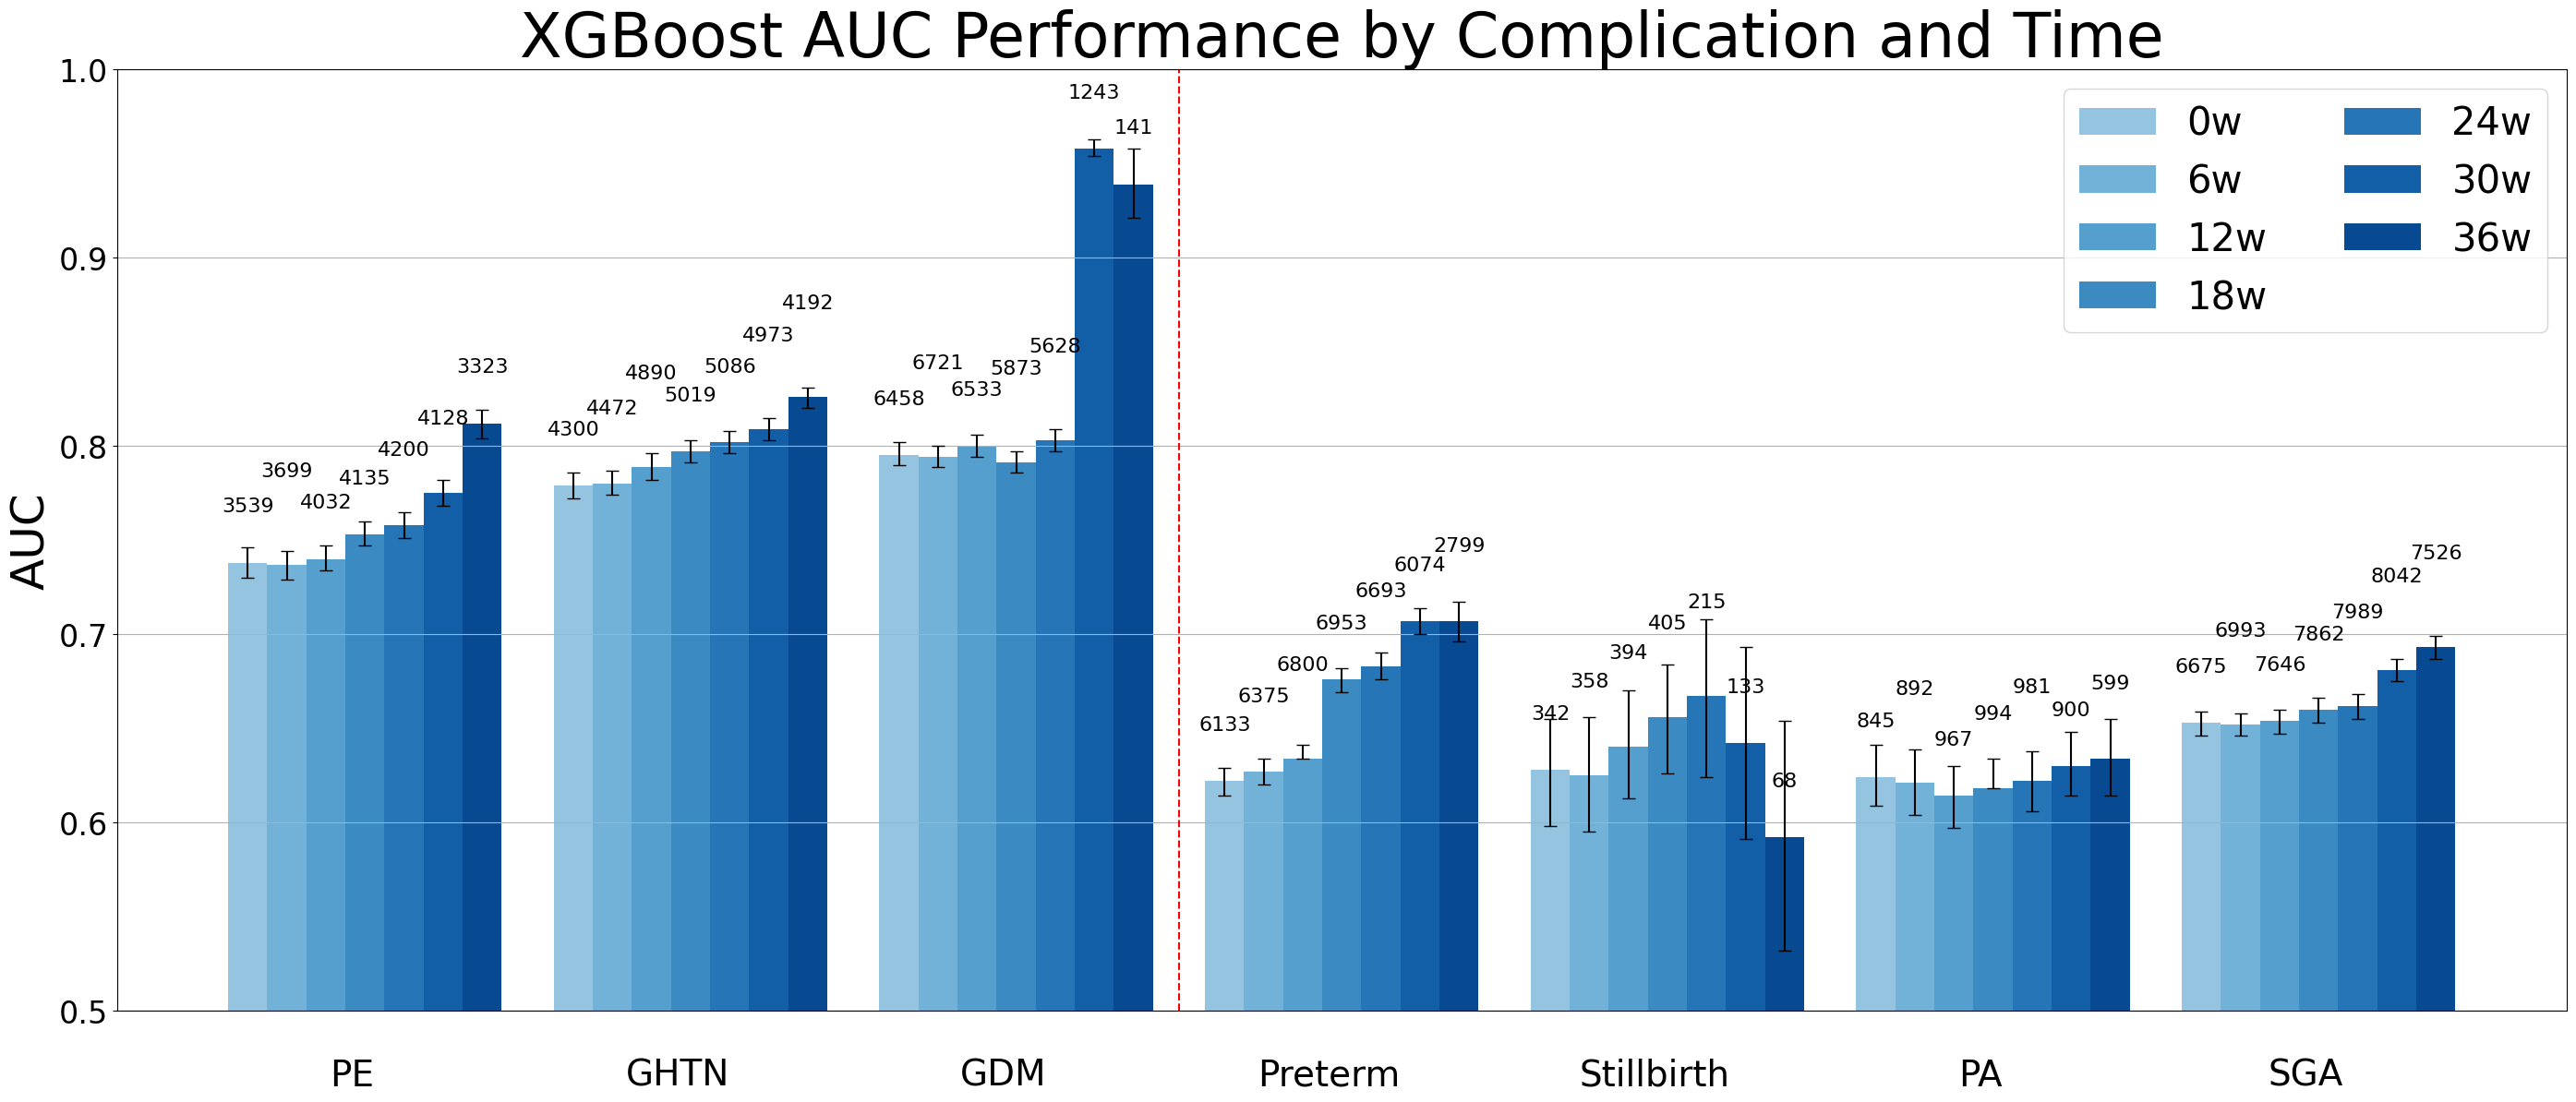

In [3]:
complications = ['PE', 'GHTN', 'GDM', 'Preterm', 'Stillbirth', 'PA', 'SGA']
years = [0, 6, 12, 18, 24, 30, 36]
colors = [cm.Blues(i) for i in np.linspace(0.4, 0.9, 7)]   
comparator_color = 'red'

performance = {
    'PE': {
        0: {'mean': 0.738, 'ci': [0.73, 0.746], 'n': 3539},
        6: {'mean': 0.737, 'ci': [0.729, 0.744], 'n': 3699},
        12: {'mean': 0.74, 'ci': [0.734, 0.747], 'n': 4032},
        18: {'mean': 0.753, 'ci': [0.747, 0.76], 'n': 4135},
        24: {'mean': 0.758, 'ci': [0.751, 0.765], 'n': 4200},
        30: {'mean': 0.775, 'ci': [0.768, 0.782], 'n': 4128},
        36: {'mean': 0.812, 'ci': [0.804, 0.819], 'n': 3323}
    },
    'GHTN': {
        0: {'mean': 0.779, 'ci': [0.772, 0.786], 'n': 4300},
        6: {'mean': 0.78, 'ci': [0.774, 0.787], 'n': 4472},
        12: {'mean': 0.789, 'ci': [0.782, 0.796], 'n': 4890},
        18: {'mean': 0.797, 'ci': [0.791, 0.803], 'n': 5019},
        24: {'mean': 0.802, 'ci': [0.796, 0.808], 'n': 5086},
        30: {'mean': 0.809, 'ci': [0.803, 0.815], 'n': 4973},
        36: {'mean': 0.826, 'ci': [0.82, 0.831], 'n': 4192}
    },
    'GDM': {
        0: {'mean': 0.795, 'ci': [0.79, 0.802], 'n': 6458},
        6: {'mean': 0.794, 'ci': [0.789, 0.8], 'n': 6721},
        12: {'mean': 0.8, 'ci': [0.794, 0.806], 'n': 6533},
        18: {'mean': 0.791, 'ci': [0.786, 0.797], 'n': 5873},
        24: {'mean': 0.803, 'ci': [0.797, 0.809], 'n': 5628},
        30: {'mean': 0.958, 'ci': [0.954, 0.963], 'n': 1243},
        36: {'mean': 0.939, 'ci': [0.921, 0.958], 'n': 141}
    },
    'Preterm': {
        0: {'mean': 0.622, 'ci': [0.614, 0.629], 'n': 6133},
        6: {'mean': 0.627, 'ci': [0.62, 0.634], 'n': 6375},
        12: {'mean': 0.634, 'ci': [0.634, 0.641], 'n': 6800},
        18: {'mean': 0.676, 'ci': [0.669, 0.682], 'n': 6953},
        24: {'mean': 0.683, 'ci': [0.676, 0.69], 'n': 6693},
        30: {'mean': 0.707, 'ci': [0.7, 0.714], 'n': 6074},
        36: {'mean': 0.707, 'ci': [0.696, 0.717], 'n': 2799}
    },
    'Stillbirth': {
        0: {'mean': 0.628, 'ci': [0.598, 0.655], 'n': 342},
        6: {'mean': 0.625, 'ci': [0.595, 0.656], 'n': 358},
        12: {'mean': 0.64, 'ci': [0.613, 0.67], 'n': 394},
        18: {'mean': 0.656, 'ci': [0.626, 0.684], 'n': 405},
        24: {'mean': 0.667, 'ci': [0.624, 0.708], 'n': 215},
        30: {'mean': 0.642, 'ci': [0.591, 0.693], 'n': 133},
        36: {'mean': 0.592, 'ci': [0.532, 0.654], 'n': 68}
    },
    'PA': {
        0: {'mean': 0.624, 'ci': [0.609, 0.641], 'n': 845},
        6: {'mean': 0.621, 'ci': [0.604, 0.639], 'n': 892},
        12: {'mean': 0.614, 'ci': [0.597, 0.63], 'n': 967},
        18: {'mean': 0.618, 'ci': [0.618, 0.634], 'n': 994},
        24: {'mean': 0.622, 'ci': [0.606, 0.638], 'n': 981},
        30: {'mean': 0.63, 'ci': [0.614, 0.648], 'n': 900},
        36: {'mean': 0.634, 'ci': [0.614, 0.655], 'n': 599}
    },
    'SGA': {
        0: {'mean': 0.653, 'ci': [0.646, 0.659], 'n': 6675},
        6: {'mean': 0.652, 'ci': [0.646, 0.658], 'n': 6993},
        12: {'mean': 0.654, 'ci': [0.647, 0.66], 'n': 7646},
        18: {'mean': 0.66, 'ci': [0.653, 0.666], 'n': 7862},
        24: {'mean': 0.662, 'ci': [0.655, 0.668], 'n': 7989},
        30: {'mean': 0.681, 'ci': [0.675, 0.687], 'n': 8042},
        36: {'mean': 0.693, 'ci': [0.687, 0.699], 'n': 7526}
    }
}

bar_width = 0.06
group_spacing = 0.5
num_complications = len(complications)
x_ticks = []
x_labels = []

fig, ax = plt.subplots(figsize=(28, 12))

placed_labels = []
bar_idx = 0
for i, complication in enumerate(complications):
    base_x = i * group_spacing

    for j, year in enumerate(years):
        x = base_x + j * bar_width
        data = performance[complication][year]
        y = data['mean']
        ci = data['ci']
        n = data['n']

        ax.bar(x, y, width=bar_width, color=colors[j], label=f"{year}w" if i == 0 else "")
        ax.errorbar(x, y, yerr=[[y - ci[0]], [ci[1] - y]], fmt='none', ecolor='black', capsize=5)
        
        label_text = f"{data['n']}"
        place_label_no_overlap(ax, x, y + 0.025, label_text, placed_labels)


        x_ticks.append(x)
        x_labels.append(f"{complication}\n{year}y")

ax.set_ylabel("AUC", fontsize=36)
ax.set_title("XGBoost AUC Performance by Complication and Time", fontsize=48)
ax.set_ylim(0.5, 1.0)
ax.tick_params(axis='x', labelsize=24) 
ax.tick_params(axis='y', labelsize=24)
ax.legend(fontsize=30, ncol=2)
ax.set_xticks([])

plt.axvline(x=1.43, color='r', linestyle='--')

for i, complication in enumerate(complications):
    group_center = i * group_spacing + bar_width + 0.1 # or adjust as needed
    ax.text(group_center, -0.05, complication,
            ha='center', va='top', fontsize=28, transform=ax.get_xaxis_transform())
plt.grid(True)
plt.tight_layout()
plt.show()

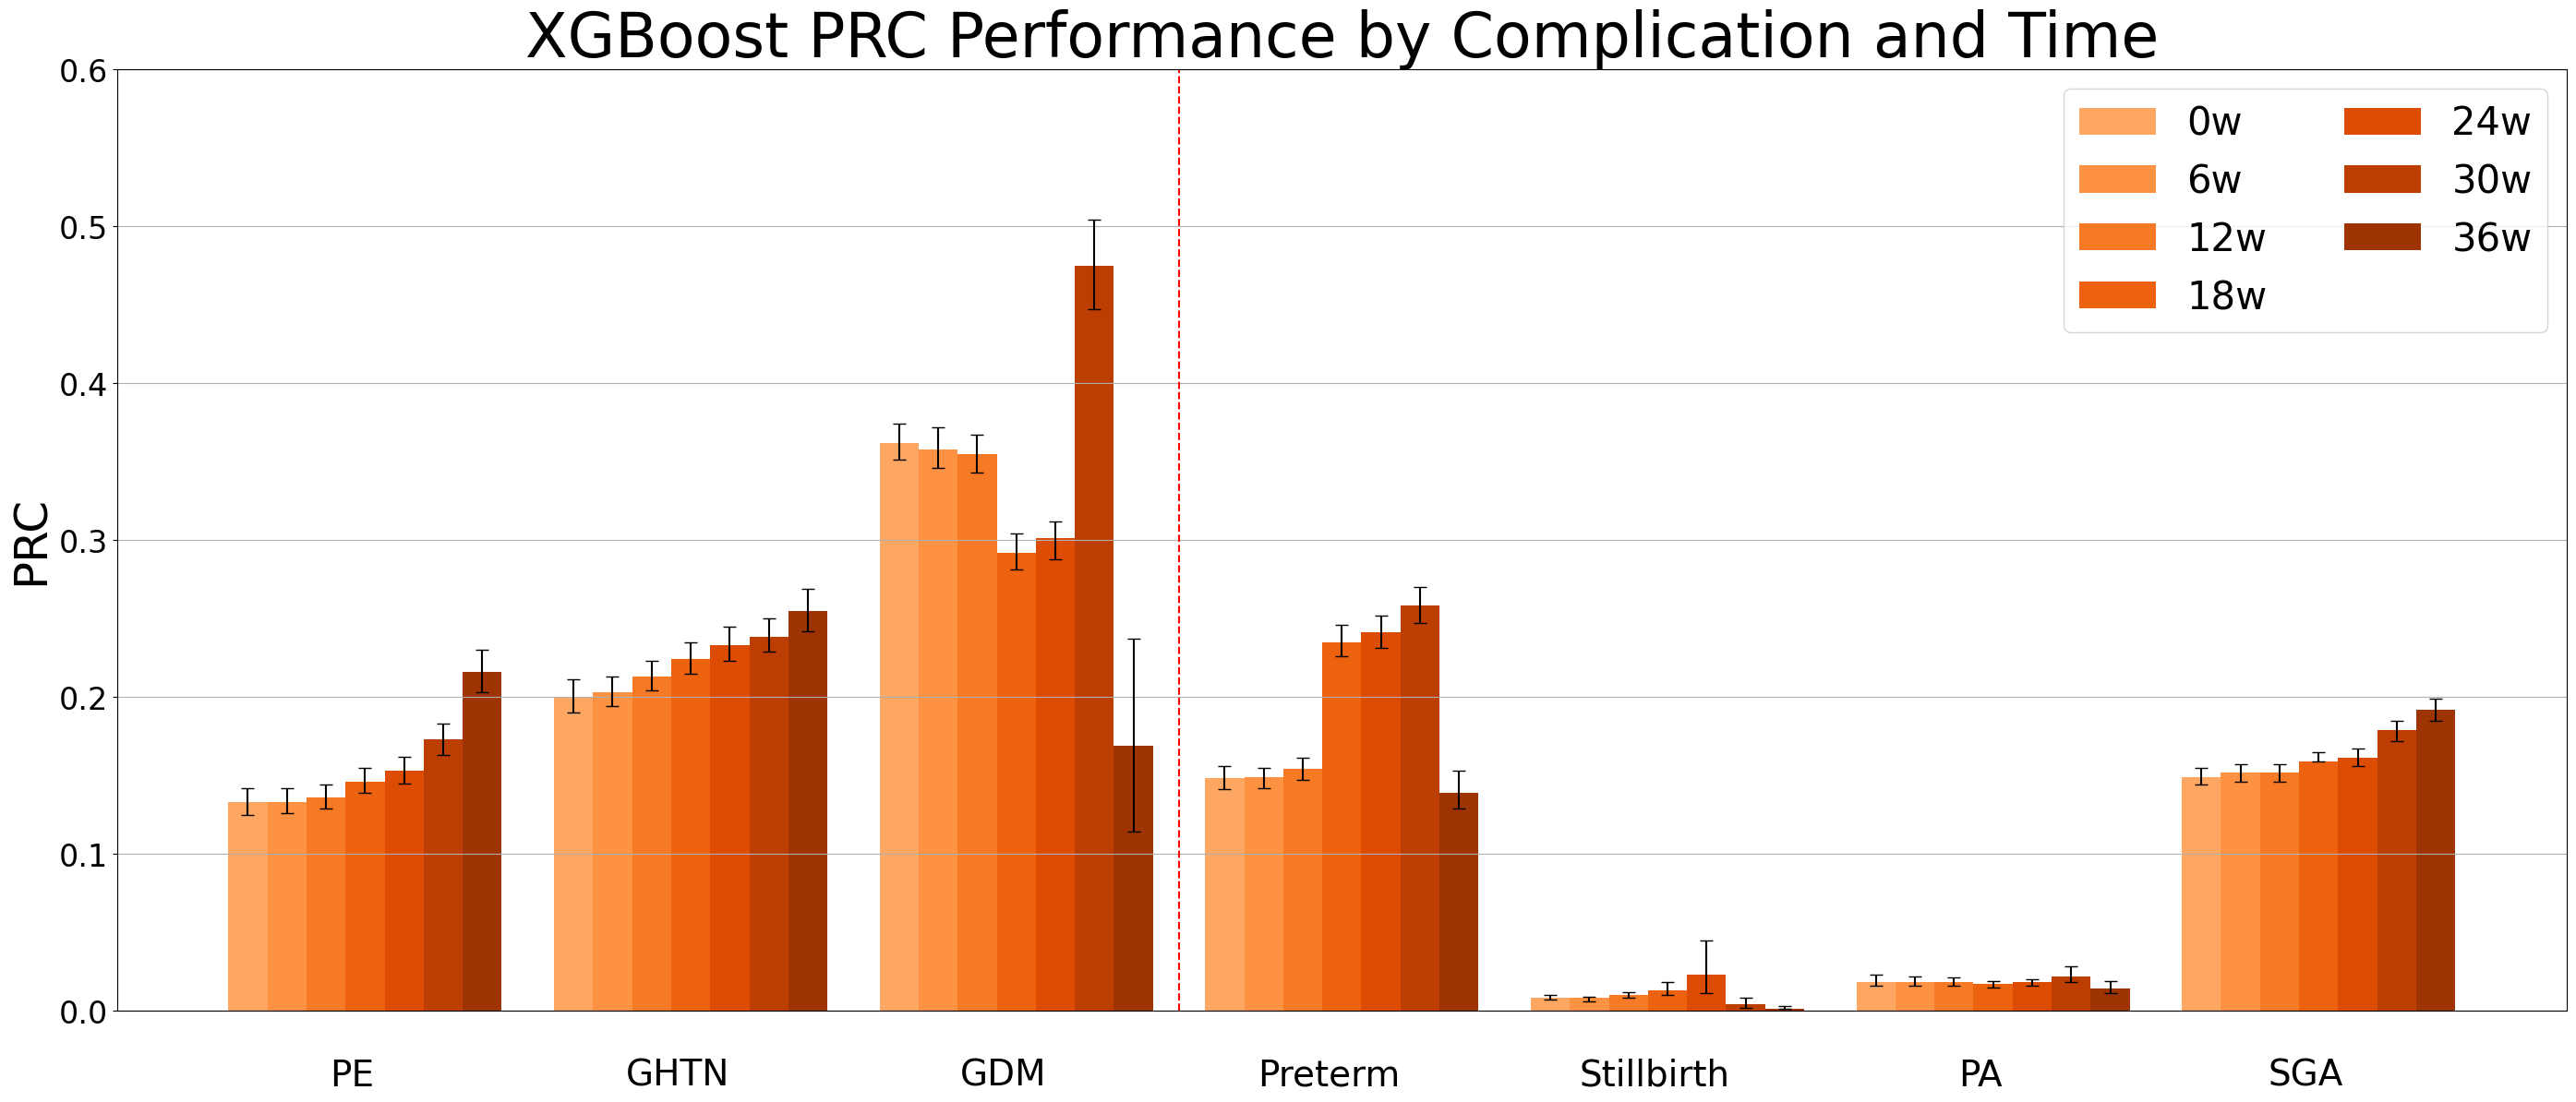

In [4]:
complications = ['PE', 'GHTN', 'GDM', 'Preterm', 'Stillbirth', 'PA', 'SGA']
years = [0, 6, 12, 18, 24, 30, 36]
colors = [cm.Oranges(i) for i in np.linspace(0.4, 0.9, 7)]   
comparator_color = 'grey'

performance = {
    'PE': {
        0: {'mean': 0.133, 'ci': [0.125, 0.142]},
        6: {'mean': 0.133, 'ci': [0.126, 0.142]},
        12: {'mean': 0.136, 'ci': [0.129, 0.144]},
        18: {'mean': 0.146, 'ci': [0.139, 0.155]},
        24: {'mean': 0.153, 'ci': [0.145, 0.162]},
        30: {'mean': 0.173, 'ci': [0.163, 0.183]},
        36: {'mean': 0.216, 'ci': [0.203, 0.23]}
    },
    'GHTN': {
        0: {'mean': 0.20, 'ci': [0.19, 0.211]},
        6: {'mean': 0.203, 'ci': [0.194, 0.213]},
        12: {'mean': 0.213, 'ci': [0.204, 0.223]},
        18: {'mean': 0.224, 'ci': [0.215, 0.235]},
        24: {'mean': 0.233, 'ci': [0.223, 0.245]},
        30: {'mean': 0.238, 'ci': [0.229, 0.25]},
        36: {'mean': 0.255, 'ci': [0.242, 0.269]}
    },
    'GDM': {
        0: {'mean': 0.362, 'ci': [0.351, 0.374]},
        6: {'mean': 0.358, 'ci': [0.346, 0.372]},
        12: {'mean': 0.355, 'ci': [0.343, 0.367]},
        18: {'mean': 0.292, 'ci': [0.281, 0.304]},
        24: {'mean': 0.301, 'ci': [0.288, 0.312]},
        30: {'mean': 0.475, 'ci': [0.447, 0.504]},
        36: {'mean': 0.169, 'ci': [0.114, 0.237]}
    },
    'Preterm': {
        0: {'mean': 0.148, 'ci': [0.141, 0.156]},
        6: {'mean': 0.149, 'ci': [0.142, 0.155]},
        12: {'mean': 0.154, 'ci': [0.147, 0.161]},
        18: {'mean': 0.235, 'ci': [0.226, 0.246]},
        24: {'mean': 0.241, 'ci': [0.231, 0.252]},
        30: {'mean': 0.258, 'ci': [0.247, 0.27]},
        36: {'mean': 0.139, 'ci': [0.129, 0.153]}
    },
    'Stillbirth': {
        0: {'mean': 0.008, 'ci': [0.007, 0.01]},
        6: {'mean': 0.008, 'ci': [0.006, 0.009]},
        12: {'mean': 0.01, 'ci': [0.008, 0.012]},
        18: {'mean': 0.013, 'ci': [0.01, 0.018]},
        24: {'mean': 0.023, 'ci': [0.011, 0.045]},
        30: {'mean': 0.004, 'ci': [0.002, 0.008]},
        36: {'mean': 0.001, 'ci': [0.001, 0.003]}
    },
    'PA': {
        0: {'mean': 0.018, 'ci': [0.016, 0.023]},
        6: {'mean': 0.018, 'ci': [0.016, 0.022]},
        12: {'mean': 0.018, 'ci': [0.016, 0.021]},
        18: {'mean': 0.017, 'ci': [0.015, 0.019]},
        24: {'mean': 0.018, 'ci': [0.016, 0.02]},
        30: {'mean': 0.022, 'ci': [0.018, 0.028]},
        36: {'mean': 0.014, 'ci': [0.011, 0.019]}
    },
    'SGA': {
        0: {'mean': 0.149, 'ci': [0.144, 0.155]},
        6: {'mean': 0.152, 'ci': [0.146, 0.157]},
        12: {'mean': 0.152, 'ci': [0.146, 0.157]},
        18: {'mean': 0.159, 'ci': [0.159, 0.165]},
        24: {'mean': 0.161, 'ci': [0.156, 0.167]},
        30: {'mean': 0.179, 'ci': [0.172, 0.185]},
        36: {'mean': 0.192, 'ci': [0.185, 0.199]}
    }
}

bar_width = 0.06
group_spacing = 0.5
num_complications = len(complications)
x_ticks = []
x_labels = []

fig, ax = plt.subplots(figsize=(28, 12))


bar_idx = 0
for i, complication in enumerate(complications):
    base_x = i * group_spacing

    for j, year in enumerate(years):
        x = base_x + j * bar_width
        data = performance[complication][year]
        y = data['mean']
        ci = data['ci']

        ax.bar(x, y, width=bar_width, color=colors[j], label=f"{year}w" if i == 0 else "")
        ax.errorbar(x, y, yerr=[[y - ci[0]], [ci[1] - y]], fmt='none', ecolor='black', capsize=5)
        
        x_ticks.append(x)
        x_labels.append(f"{complication}\n{year}y")


ax.set_ylabel("PRC", fontsize=36)
ax.set_title("XGBoost PRC Performance by Complication and Time", fontsize=48)
ax.set_ylim(0, 0.6)
ax.tick_params(axis='x', labelsize=24) 
ax.tick_params(axis='y', labelsize=24)
ax.legend(fontsize=30, ncol=2)
ax.set_xticks([])

for i, complication in enumerate(complications):
    group_center = i * group_spacing + bar_width + 0.1 # or adjust as needed
    ax.text(group_center, -0.05, complication,
            ha='center', va='top', fontsize=28, transform=ax.get_xaxis_transform())
plt.axvline(x=1.43, color='r', linestyle='--')
plt.tight_layout()
plt.grid(True)
plt.show()

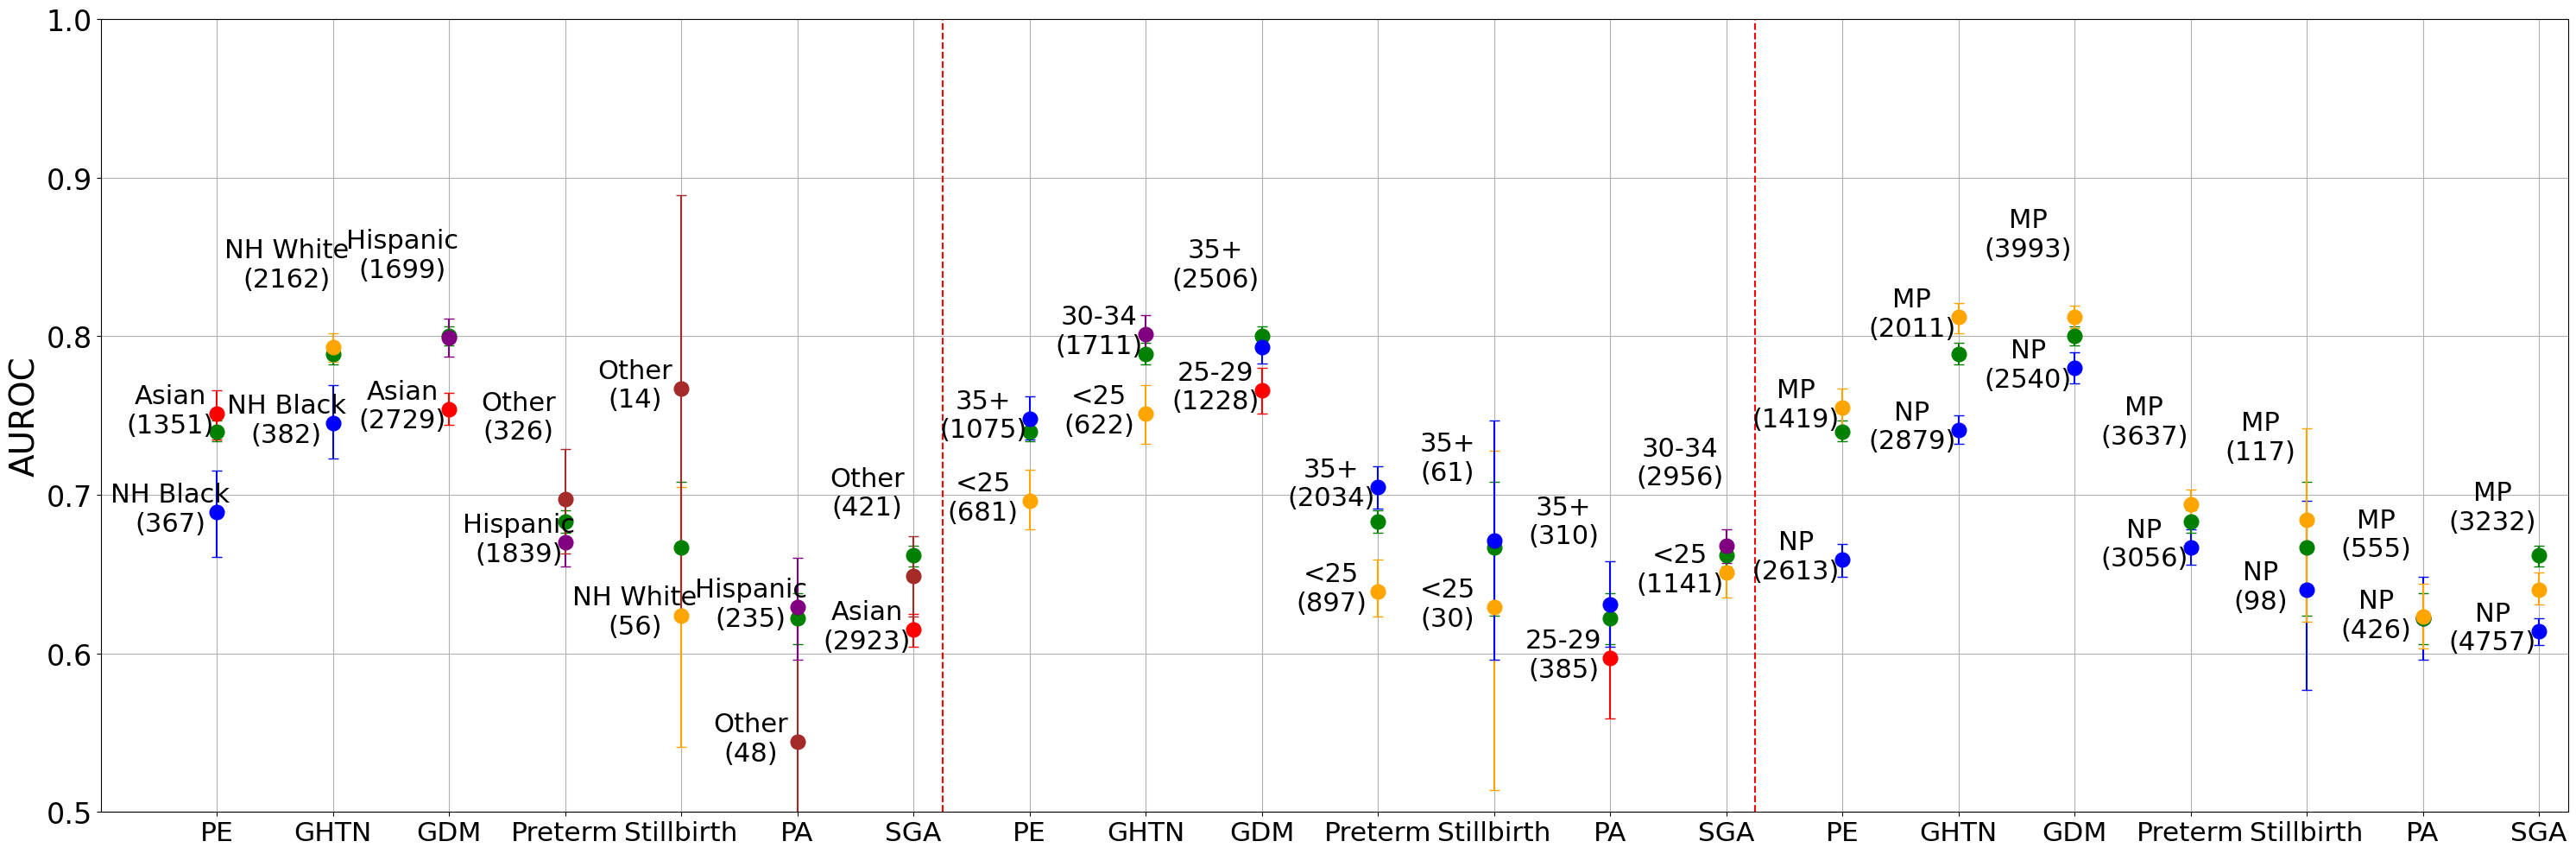

In [9]:
complications = ['PE', 'GHTN', 'GDM', 'Preterm', 'Stillbirth', 'PA', 'SGA']
performance_levels = ['Low', 'Medium', 'High']

colors = {
    'NH Black': 'blue',
    'Asian': 'red',
    'NH White': 'orange',
    'Hispanic': 'purple',
    'Other': 'brown',
    '<25': 'orange',
    '25-29': 'red',
    '30-34': 'purple',
    '35+': 'blue',
    'NP': 'blue',
    'MP': 'orange',
    'Overall': 'green'
}
offsets = [-0.2, 0, 0.2]  

###RACE
performance_r = {
    'PE': {
        'Low': {'mean': 0.689, 'ci_low': 0.661, 'ci_high': 0.715, 'n': 367, 'label': 'NH Black'},
        'Medium': {'mean': 0.74, 'ci_low': 0.734, 'ci_high': 0.747, 'n': 4032, 'label': 'Overall'},
        'High': {'mean': 0.751, 'ci_low': 0.735, 'ci_high': 0.766, 'n': 1351, 'label': 'Asian'}
    },
    'GHTN': {
        'Low': {'mean': 0.745, 'ci_low': 0.723, 'ci_high': 0.769, 'n': 382, 'label': 'NH Black'},
        'Medium': {'mean': 0.789, 'ci_low': 0.782, 'ci_high': 0.796, 'n': 4890, 'label': 'Overall'},
        'High': {'mean': 0.793, 'ci_low': 0.784, 'ci_high': 0.802, 'n': 2162, 'label': 'NH White'}
    },
    'GDM': {
        'Low': {'mean': 0.754, 'ci_low': 0.744, 'ci_high': 0.764, 'n': 2729, 'label': 'Asian'},
        'Medium': {'mean': 0.8, 'ci_low': 0.794, 'ci_high': 0.806, 'n': 6533, 'label': 'Overall'},
        'High': {'mean': 0.799, 'ci_low': 0.787, 'ci_high': 0.811, 'n': 1699, 'label': 'Hispanic'}
    },
    'Preterm': {
        'Low': {'mean': 0.67, 'ci_low': 0.655, 'ci_high': 0.685, 'n': 1839, 'label': 'Hispanic'},
        'Medium': {'mean': 0.683, 'ci_low': 0.676, 'ci_high': 0.69, 'n': 6693, 'label': 'Overall'},
        'High': {'mean': 0.697, 'ci_low': 0.663, 'ci_high': 0.729, 'n': 326, 'label': 'Other'}
    },
    'Stillbirth': {
        'Low': {'mean': 0.624, 'ci_low': 0.541, 'ci_high': 0.705, 'n': 56, 'label': 'NH White'},
        'Medium': {'mean': 0.667, 'ci_low': 0.624, 'ci_high': 0.708, 'n': 215, 'label': 'Overall'},
        'High': {'mean': 0.767, 'ci_low': 0.622, 'ci_high': 0.889, 'n': 14, 'label': 'Other'}
    },
     'PA': {
        'Low': {'mean': 0.544, 'ci_low': 0.464, 'ci_high': 0.621, 'n': 48, 'label': 'Other'},
        'Medium': {'mean': 0.622, 'ci_low': 0.606, 'ci_high': 0.638, 'n': 981, 'label': 'Overall'},
        'High': {'mean': 0.629, 'ci_low': 0.596, 'ci_high': 0.66, 'n': 235, 'label': 'Hispanic'}
    },
    'SGA': {
        'Low': {'mean': 0.615, 'ci_low': 0.604, 'ci_high': 0.625, 'n': 2923, 'label': 'Asian'},
        'Medium': {'mean': 0.662, 'ci_low': 0.655, 'ci_high': 0.668, 'n': 7989, 'label': 'Overall'},
        'High': {'mean': 0.649, 'ci_low': 0.623, 'ci_high': 0.674, 'n': 421, 'label': 'Other'}
    }
}

###AGE    
performance_a = {
    'PE': {
        'Low': {'mean': 0.696, 'ci_low': 0.678, 'ci_high': 0.716, 'n': 681, 'label': '<25'},
        'Medium': {'mean': 0.74, 'ci_low': 0.734, 'ci_high': 0.747, 'n': 4032, 'label': 'Overall'},
        'High': {'mean': 0.748, 'ci_low': 0.735, 'ci_high': 0.762, 'n': 1075, 'label': '35+'}
    },
    'GHTN': {
        'Low': {'mean': 0.751, 'ci_low': 0.732, 'ci_high': 0.769, 'n': 622, 'label': '<25'},
        'Medium': {'mean': 0.789, 'ci_low': 0.782, 'ci_high': 0.796, 'n': 4890, 'label': 'Overall'},
        'High': {'mean': 0.801, 'ci_low': 0.792, 'ci_high': 0.813, 'n': 1711, 'label': '30-34'}
    },
    'GDM': {
        'Low': {'mean': 0.766, 'ci_low': 0.751, 'ci_high': 0.78, 'n': 1228, 'label': '25-29'},
        'Medium': {'mean': 0.8, 'ci_low': 0.794, 'ci_high': 0.806, 'n': 6533, 'label': 'Overall'},
        'High': {'mean': 0.793, 'ci_low': 0.783, 'ci_high': 0.802, 'n': 2506, 'label': '35+'}
    },
    'Preterm': {
        'Low': {'mean': 0.639, 'ci_low': 0.623, 'ci_high': 0.659, 'n': 897, 'label': '<25'},
        'Medium': {'mean': 0.683, 'ci_low': 0.676, 'ci_high': 0.69, 'n': 6693, 'label': 'Overall'},
        'High': {'mean': 0.705, 'ci_low': 0.691, 'ci_high': 0.718, 'n': 2034, 'label': '35+'}
    },
    'Stillbirth': {
        'Low': {'mean': 0.629, 'ci_low': 0.514, 'ci_high': 0.728, 'n': 30, 'label': '<25'},
        'Medium': {'mean': 0.667, 'ci_low': 0.624, 'ci_high': 0.708, 'n': 215, 'label': 'Overall'},
        'High': {'mean': 0.671, 'ci_low': 0.596, 'ci_high': 0.747, 'n': 61, 'label': '35+'}
    },
    'PA': {
        'Low': {'mean': 0.597, 'ci_low': 0.559, 'ci_high': 0.628, 'n': 385, 'label': '25-29'},
        'Medium': {'mean': 0.622, 'ci_low': 0.606, 'ci_high': 0.638, 'n': 981, 'label': 'Overall'},
        'High': {'mean': 0.631, 'ci_low': 0.604, 'ci_high': 0.658, 'n': 310, 'label': '35+'}
     },
    'SGA': {
        'Low': {'mean': 0.651, 'ci_low': 0.635, 'ci_high': 0.666, 'n': 1141, 'label': '<25'},
        'Medium': {'mean': 0.662, 'ci_low': 0.655, 'ci_high': 0.668, 'n': 7989, 'label': 'Overall'},
        'High': {'mean': 0.668, 'ci_low': 0.657, 'ci_high': 0.678, 'n': 2956, 'label': '30-34'}
    }
}
    
###PARITY
performance_p = {   
    'PE': {
        'Low': {'mean': 0.659, 'ci_low': 0.648, 'ci_high': 0.669, 'n': 2613, 'label': 'NP'},
        'Medium': {'mean': 0.74, 'ci_low': 0.734, 'ci_high': 0.747, 'n': 4032, 'label': 'Overall'},
        'High': {'mean': 0.755, 'ci_low': 0.74, 'ci_high': 0.767, 'n': 1419, 'label': 'MP'}
    },
    'GHTN': {
        'Low': {'mean': 0.741, 'ci_low': 0.732, 'ci_high': 0.75, 'n': 2879, 'label': 'NP'},
        'Medium': {'mean': 0.789, 'ci_low': 0.782, 'ci_high': 0.796, 'n': 4890, 'label': 'Overall'},
        'High': {'mean': 0.812, 'ci_low': 0.802, 'ci_high': 0.821, 'n': 2011, 'label': 'MP'}
    },
    'GDM': {
        'Low': {'mean': 0.78, 'ci_low': 0.77, 'ci_high': 0.79, 'n': 2540, 'label': 'NP'},
        'Medium': {'mean': 0.8, 'ci_low': 0.794, 'ci_high': 0.806, 'n': 6533, 'label': 'Overall'},
        'High': {'mean': 0.812, 'ci_low': 0.805, 'ci_high': 0.819, 'n': 3993, 'label': 'MP'}
    },
    'Preterm': {
        'Low': {'mean': 0.667, 'ci_low': 0.656, 'ci_high': 0.678, 'n': 3056, 'label': 'NP'},
        'Medium': {'mean': 0.683, 'ci_low': 0.676, 'ci_high': 0.69, 'n': 6693, 'label': 'Overall'},
        'High': {'mean': 0.694, 'ci_low': 0.684, 'ci_high': 0.703, 'n': 3637, 'label': 'MP'}
    },
    'Stillbirth': {
        'Low': {'mean': 0.64, 'ci_low': 0.577, 'ci_high': 0.696, 'n': 98, 'label': 'NP'},
        'Medium': {'mean': 0.667, 'ci_low': 0.624, 'ci_high': 0.708, 'n': 215, 'label': 'Overall'},
        'High': {'mean': 0.684, 'ci_low': 0.62, 'ci_high': 0.742, 'n': 117, 'label': 'MP'}
    },
    'PA': {
        'Low': {'mean': 0.622, 'ci_low': 0.596, 'ci_high': 0.648, 'n': 426, 'label': 'NP'},
        'Medium': {'mean': 0.622, 'ci_low': 0.606, 'ci_high': 0.638, 'n': 981, 'label': 'Overall'},
        'High': {'mean': 0.623, 'ci_low': 0.603, 'ci_high': 0.644, 'n': 555, 'label': 'MP'}
     },
    'SGA': {
        'Low': {'mean': 0.614, 'ci_low': 0.605, 'ci_high': 0.622, 'n': 4757, 'label': 'NP'},
        'Medium': {'mean': 0.662, 'ci_low': 0.655, 'ci_high': 0.668, 'n': 7989, 'label': 'Overall'},
        'High': {'mean': 0.64, 'ci_low': 0.631, 'ci_high': 0.651, 'n': 3232, 'label': 'MP'}
    }  
}

fig, ax = plt.subplots(figsize=(30, 10))
placed_labels = []
perf_types = [performance_r, performance_a, performance_p]
count = 0
for performance in perf_types:
    for i, complication in enumerate(complications):
        for j, level in enumerate(performance_levels):
            data = performance[complication][level]
            x = i + count
            y = data['mean'] 
            ci_low = data['ci_low'] 
            ci_high = data['ci_high']
            curr_color = colors[str(data['label'])]

            if data['label'] != 'Overall':
                label_text = data['label'] + "\n(" + str(data['n']) + ")"
                place_label_no_overlap(ax, x - 0.4, y-0.015, label_text, placed_labels, min_sep=0.05, cut=0.1, font_size=22)
                

            ax.errorbar(x, y, yerr=[[y - ci_low], [ci_high - y]], markersize=12,
                        fmt='o', color=curr_color, capsize=4)
    count +=7
            

all_labels = complications + complications + complications
ax.set_xticks(range(len(all_labels)))
ax.tick_params(axis='x', labelsize=24) 
ax.tick_params(axis='y', labelsize=24)

ax.set_xticklabels(all_labels, fontsize=22.5)
ax.set_ylabel("AUROC", fontsize=28)
ax.set_ylim(0.5, 1.0)
ax.set_xlim(-1.0, 20.25)

plt.axvline(x=6.25, color='r', linestyle='--')
plt.axvline(x=13.25, color='r', linestyle='--')

handles, labels = ax.get_legend_handles_labels()
unique = dict(zip(labels, handles))

plt.tight_layout()
plt.grid(True)
plt.show()

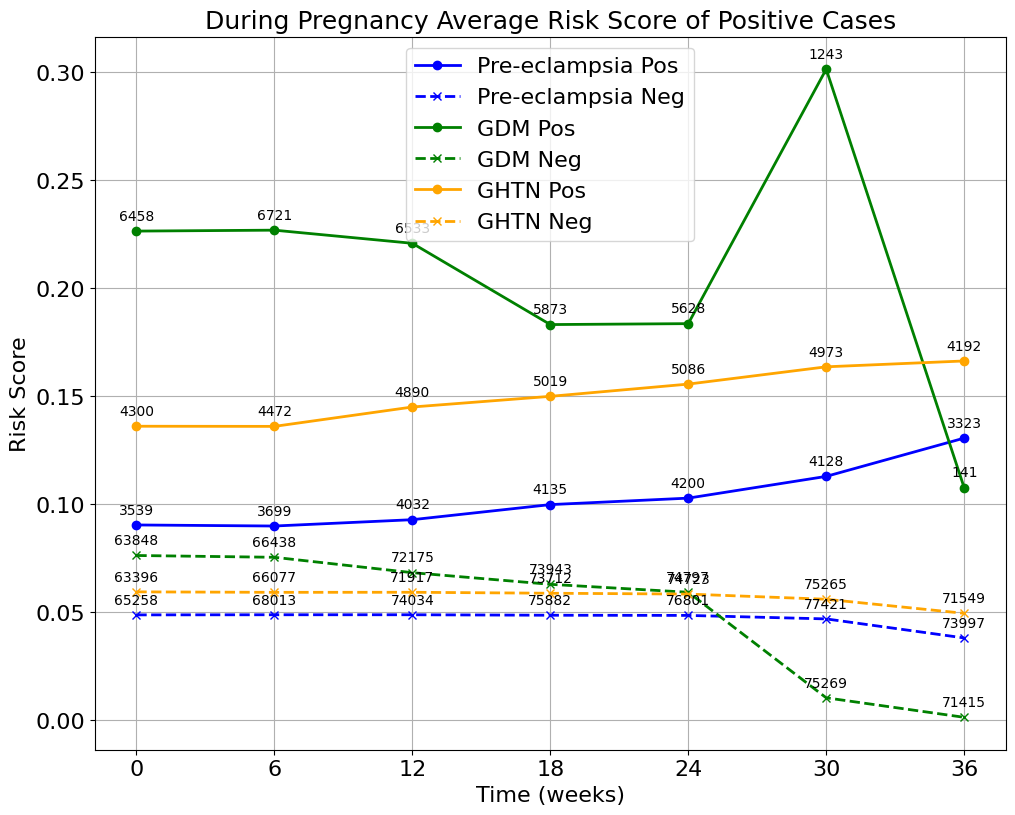

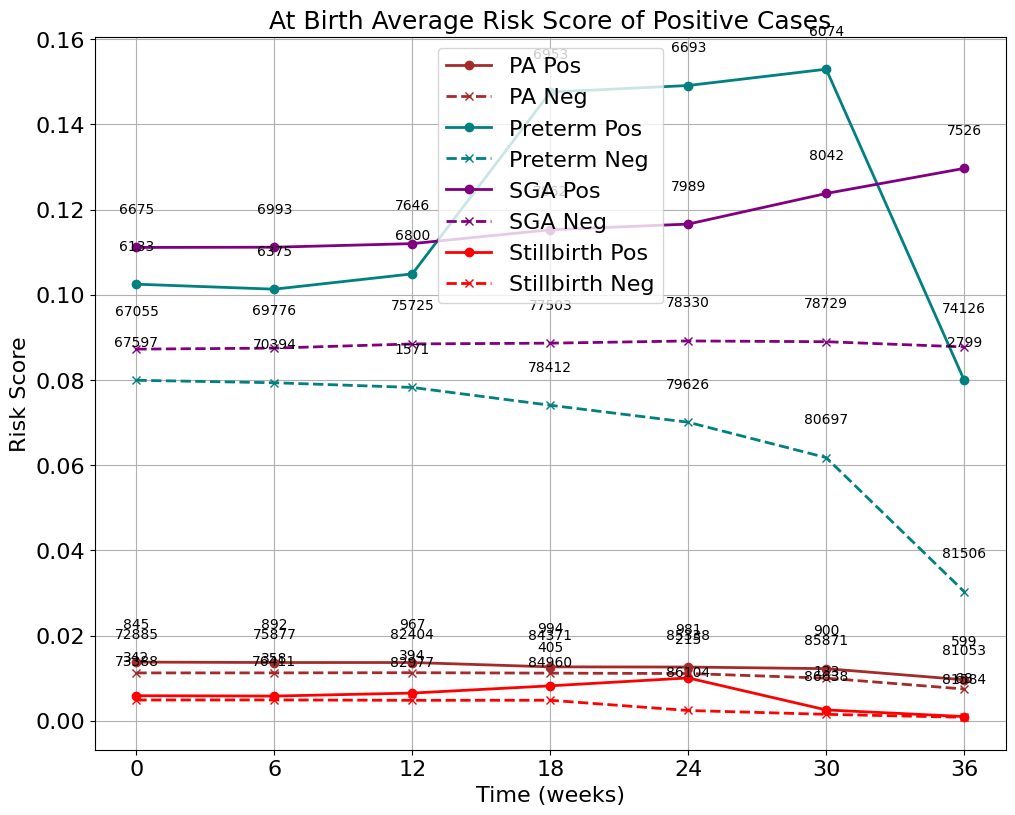

In [8]:
time_vals =[0, 6, 12, 18, 24, 30, 36]

pe_pos = [0.09049, 0.09, 0.09293, 0.09991, 0.10291, 0.11297, 0.13069]
pe_neg = [0.04887, 0.04893, 0.04893, 0.04871, 0.04863, 0.04701, 0.0382]
pe_labels_pos = [3539, 3699, 4032, 4135, 4200, 4128, 3323]
pe_total = [68797, 71712, 78066, 80017, 81001, 81549, 77320]
pe_labels_neg = [x - y for x, y in zip(pe_total, pe_labels_pos)]

gdm_pos = [0.22649, 0.22692, 0.22084, 0.18323, 0.18366, 0.30142, 0.10774]
gdm_neg = [0.07636, 0.07553, 0.06841, 0.06302, 0.05934, 0.0105, 0.00147]
gdm_labels_pos = [6458, 6721, 6533, 5873, 5628, 1243, 141]
gdm_total = [70306, 73159, 78708, 79816, 80425, 76512, 71556]
gdm_labels_neg = [x - y for x, y in zip(gdm_total, gdm_labels_pos)]

ghtn_pos = [0.13618, 0.13611, 0.14508, 0.15001, 0.15568, 0.16368, 0.16639]
ghtn_neg = [0.05953, 0.05931, 0.05934, 0.05889, 0.05851, 0.05611, 0.0496]
ghtn_labels_pos = [4300, 4472, 4890, 5019, 5086, 4973, 4192]
ghtn_total = [67696, 70549, 76807, 78731, 79809, 80238, 75741]
ghtn_labels_neg = [x - y for x, y in zip(ghtn_total, ghtn_labels_pos)]

plt.figure(figsize=(10, 8))
     
plt.plot(time_vals, pe_pos, label=f"Pre-eclampsia Pos", color='blue', marker='o', linewidth = 2)
plt.plot(time_vals, pe_neg, label=f"Pre-eclampsia Neg", color='blue', marker='x', linewidth = 2, linestyle="dashed")

plt.plot(time_vals, gdm_pos, label=f"GDM Pos", color='green', marker='o', linewidth = 2)
plt.plot(time_vals, gdm_neg, label=f"GDM Neg", color='green', marker='x', linewidth = 2, linestyle="dashed")

plt.plot(time_vals, ghtn_pos, label=f"GHTN Pos", color='orange', marker='o', linewidth = 2)
plt.plot(time_vals, ghtn_neg, label=f"GHTN Neg", color='orange', marker='x', linewidth = 2, linestyle="dashed")

labels = [pe_labels_pos, pe_labels_neg, gdm_labels_pos, gdm_labels_neg, ghtn_labels_pos, ghtn_labels_neg]
preg = [pe_pos, pe_neg, gdm_pos, gdm_neg, ghtn_pos, ghtn_neg]
for j in range(len(preg)):
    for i, txt in enumerate(labels[j]):
            plt.annotate(txt, (time_vals[i], preg[j][i]), xytext=(time_vals[i] + 0.001, preg[j][i] + 0.005),
                         textcoords='data', ha='center')
        
plt.title("During Pregnancy Average Risk Score of Positive Cases", fontsize=18)

plt.tick_params(axis='x', labelsize=16) 
plt.tick_params(axis='y', labelsize=16)
plt.legend(fontsize=16)
plt.grid(True)
plt.tight_layout()
plt.ylabel("Risk Score", fontsize=16)
plt.xlabel("Time (weeks)", fontsize=16)
plt.xticks(ticks = [0, 6, 12, 18, 24, 30, 36])
plt.show()


pa_pos = [0.01381, 0.01371, 0.01371, 0.01269, 0.01265, 0.01227, 0.00966]
pa_neg = [0.01127, 0.01128, 0.01132, 0.01122, 0.01113, 0.01004, 0.00749]
pa_labels_pos = [845, 892, 967, 994, 981, 900, 599]
pa_total = [73730, 76769, 83371, 85365, 86319, 86771, 81652]
pa_labels_neg = [x - y for x, y in zip(pa_total, pa_labels_pos)]

preterm_pos = [0.1025, 0.10133, 0.10492, 0.14758, 0.14913, 0.15296, 0.07998]
preterm_neg = [0.07995, 0.07937, 0.07827, 0.07409, 0.0701, 0.0618, 0.03035]
preterm_labels_pos = [6133, 6375, 6800, 6953, 6693, 6074, 2799]
preterm_total = [73730, 76769, 8371, 85365, 86319, 86771, 84305]
preterm_labels_neg = [x - y for x, y in zip(preterm_total, preterm_labels_pos)]

sga_pos = [0.11112, 0.11118, 0.11202, 0.11527, 0.11661, 0.12379, 0.12968]
sga_neg = [0.08726, 0.0875, 0.08848, 0.08866, 0.08918, 0.089, 0.08778]
sga_labels_pos = [6675, 6993, 7646, 7862, 7989, 8042, 7526]
sga_total = [73730, 76769, 83371, 85365, 86319, 86771, 81652]
sga_labels_neg = [x - y for x, y in zip(sga_total, sga_labels_pos)]

still_pos = [0.00592, 0.00584, 0.00654, 0.00824, 0.01009, 0.00258, 0.00103]
still_neg = [0.00491, 0.00493, 0.00484, 0.00485, 0.00245, 0.00155, 0.00085]
still_labels_pos = [342, 358, 394, 405, 215, 133, 68]
still_total = [73730, 76769, 83371, 85365, 86319, 86771, 81652]
still_labels_neg = [x - y for x, y in zip(still_total, still_labels_pos)]


plt.figure(figsize=(10, 8))
 
plt.plot(time_vals, pa_pos, label=f"PA Pos", color='brown', marker='o', linewidth = 2)
plt.plot(time_vals, pa_neg, label=f"PA Neg", color='brown', marker='x', linewidth = 2, linestyle="dashed")

plt.plot(time_vals, preterm_pos, label=f"Preterm Pos", color='teal', marker='o', linewidth = 2)
plt.plot(time_vals, preterm_neg, label=f"Preterm Neg", color='teal', marker='x', linewidth = 2, linestyle="dashed")

plt.plot(time_vals, sga_pos, label=f"SGA Pos", color='purple', marker='o', linewidth = 2)
plt.plot(time_vals, sga_neg, label=f"SGA Neg", color='purple', marker='x', linewidth = 2, linestyle="dashed")

plt.plot(time_vals, still_pos, label=f"Stillbirth Pos", color='red', marker='o', linewidth = 2)
plt.plot(time_vals, still_neg, label=f"Stillbirth Neg", color='red', marker='x', linewidth = 2, linestyle="dashed")


labels = [pa_labels_pos, pa_labels_neg, preterm_labels_pos, preterm_labels_neg, sga_labels_pos, sga_labels_neg, still_labels_pos, still_labels_neg]
preg = [pa_pos, pa_neg, preterm_pos, preterm_neg, sga_pos, sga_neg, still_pos, still_neg]
for j in range(len(preg)):
    for i, txt in enumerate(labels[j]):
            plt.annotate(txt, (time_vals[i], preg[j][i]), xytext=(time_vals[i] + 0.001, preg[j][i] + 0.008),
                         textcoords='data', ha='center')

            
plt.title("At Birth Average Risk Score of Positive Cases", fontsize=18)

plt.tick_params(axis='x', labelsize=16) 
plt.tick_params(axis='y', labelsize=16)
plt.legend(fontsize=16)
plt.grid(True)
plt.tight_layout()
plt.ylabel("Risk Score", fontsize=16)
plt.xlabel("Time (weeks)", fontsize=16)
plt.xticks(ticks = [0, 6, 12, 18, 24, 30, 36])
plt.show()



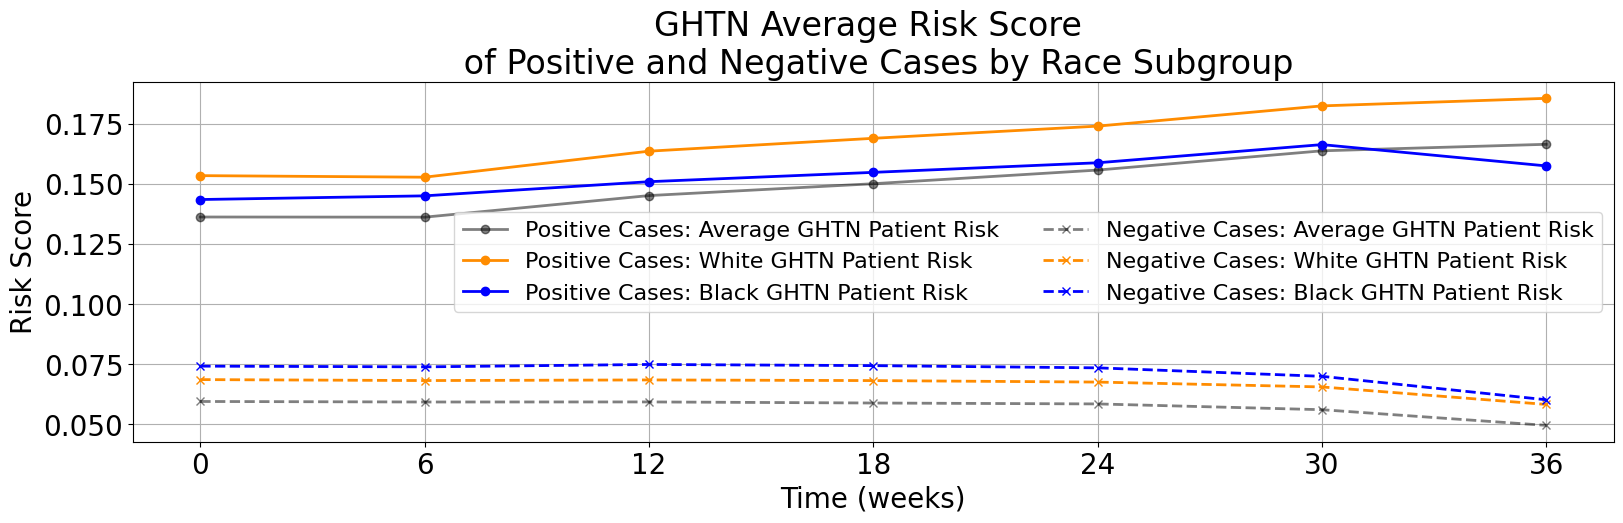

In [6]:
time_vals =[0, 6, 12, 18, 24, 30, 36]

ghtn_up = [0.13618, 0.13611, 0.14508, 0.15001, 0.15568, 0.16368, 0.16639]
ghtn_white_up = [0.15337, 0.15272, 0.16353, 0.16888, 0.17394, 0.18235, 0.18549]
ghtn_black_up = [0.14344, 0.14497, 0.15085, 0.15473, 0.15871, 0.16626, 0.15741]

ghtn_down = [0.05953, 0.05931, 0.05934, 0.05889, 0.05851, 0.05611, 0.0496]
ghtn_white_down = [0.06862, 0.06822, 0.06848, 0.06821, 0.06759, 0.06557, 0.0583]
ghtn_black_down = [0.07421, 0.07391, 0.07491, 0.07442, 0.0735, 0.06998, 0.06024]

plt.figure(figsize=(16, 5))

plt.plot(time_vals, ghtn_up, label=f"Positive Cases: Average GHTN Patient Risk", color='black', marker='o', alpha=0.5, linewidth = 2)
plt.plot(time_vals, ghtn_white_up, label=f"Positive Cases: White GHTN Patient Risk", color='darkorange', marker='o', linewidth = 2)
plt.plot(time_vals, ghtn_black_up, label=f"Positive Cases: Black GHTN Patient Risk", color='blue', marker='o', linewidth = 2)

plt.plot(time_vals, ghtn_down, label=f"Negative Cases: Average GHTN Patient Risk", color='black', marker='x', alpha = 0.5, linewidth = 2, linestyle='dashed')
plt.plot(time_vals, ghtn_white_down, label=f"Negative Cases: White GHTN Patient Risk", color='darkorange', marker='x', linewidth = 2, linestyle='dashed')
plt.plot(time_vals, ghtn_black_down, label=f"Negative Cases: Black GHTN Patient Risk", color='blue', marker='x', linewidth = 2, linestyle='dashed')

plt.title("GHTN Average Risk Score \n of Positive and Negative Cases by Race Subgroup", fontsize=24)

plt.tick_params(axis='x', labelsize=20) 
plt.tick_params(axis='y', labelsize=20)
plt.legend(fontsize=16, ncol=2)
plt.grid(True)
plt.tight_layout()
plt.ylabel("Risk Score", fontsize=20)
plt.xlabel("Time (weeks)", fontsize=20)
plt.xticks(ticks = [0, 6, 12, 18, 24, 30, 36])
plt.show()

## External Val 

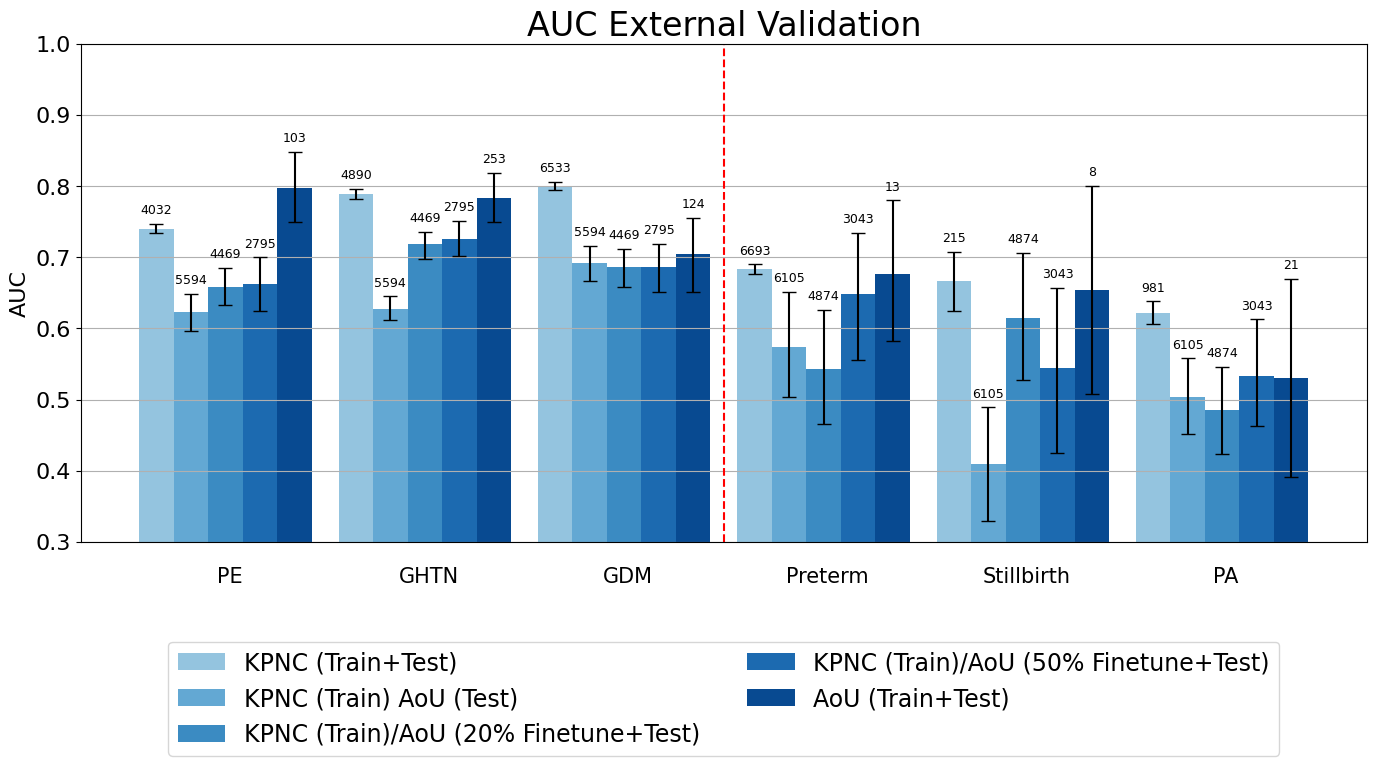

In [7]:
fig, ax = plt.subplots(figsize=(14, 8))
    
complications = ['PE', 'GHTN', 'GDM', 'Preterm', 'Stillbirth', 'PA']
years = ['KPNC (Train+Test)', 'KPNC (Train) AoU (Test)', 'KPNC (Train)/AoU (20% Finetune+Test)',
         'KPNC (Train)/AoU (50% Finetune+Test)', 'AoU (Train+Test)']
colors = [cm.Blues(i) for i in np.linspace(0.4, 0.9, 5)]   
comparator_color = 'red'

performance = {
    'PE': { 
        'KPNC (Train+Test)': {'mean': 0.740, 'ci': [0.734, 0.747], 'n': 4032},
        'KPNC (Train) AoU (Test)': {'mean': 0.623, 'ci': [0.597, 0.649], 'n': 5594},
        'KPNC (Train)/AoU (20% Finetune+Test)': {'mean': 0.659, 'ci': [0.633, 0.685], 'n': 4469},
        'KPNC (Train)/AoU (50% Finetune+Test)': {'mean': 0.662, 'ci': [0.625, 0.70], 'n': 2795},
        'AoU (Train+Test)': {'mean': 0.798, 'ci': [0.750, 0.848], 'n': 103},
    },
    'GHTN': {
        'KPNC (Train+Test)': {'mean': 0.789, 'ci': [0.782, 0.796], 'n': 4890},
        'KPNC (Train) AoU (Test)': {'mean': 0.628, 'ci': [0.612, 0.645], 'n': 5594},
        'KPNC (Train)/AoU (20% Finetune+Test)': {'mean': 0.719, 'ci': [0.698, 0.736], 'n': 4469},
        'KPNC (Train)/AoU (50% Finetune+Test)': {'mean': 0.726, 'ci': [0.702, 0.751], 'n': 2795},
        'AoU (Train+Test)': {'mean': 0.783, 'ci': [0.749, 0.819], 'n': 253},
    },
    'GDM': {
        'KPNC (Train+Test)': {'mean': 0.800, 'ci': [0.794, 0.806], 'n': 6533},
        'KPNC (Train) AoU (Test)': {'mean': 0.692, 'ci': [0.667, 0.716], 'n': 5594},
        'KPNC (Train)/AoU (20% Finetune+Test)': {'mean': 0.686, 'ci': [0.659, 0.712], 'n': 4469},
        'KPNC (Train)/AoU (50% Finetune+Test)': {'mean': 0.687, 'ci': [0.651, 0.719], 'n': 2795},
        'AoU (Train+Test)': {'mean': 0.705, 'ci': [0.651, 0.756], 'n': 124},
    },
    'Preterm': {
        'KPNC (Train+Test)': {'mean': 0.683, 'ci': [0.676, 0.690], 'n': 6693},
        'KPNC (Train) AoU (Test)': {'mean': 0.574, 'ci': [0.503, 0.651], 'n': 6105},
        'KPNC (Train)/AoU (20% Finetune+Test)': {'mean': 0.543, 'ci': [0.466, 0.626], 'n': 4874},
        'KPNC (Train)/AoU (50% Finetune+Test)': {'mean': 0.648, 'ci': [0.556, 0.734], 'n': 3043},
        'AoU (Train+Test)': {'mean': 0.677, 'ci': [0.583, 0.780], 'n': 13},
    },
    'Stillbirth': {
        'KPNC (Train+Test)': {'mean': 0.667, 'ci': [0.624, 0.708], 'n': 215},
        'KPNC (Train) AoU (Test)': {'mean': 0.409, 'ci': [0.330, 0.489], 'n': 6105},
        'KPNC (Train)/AoU (20% Finetune+Test)': {'mean': 0.615, 'ci': [0.528, 0.706], 'n': 4874},
        'KPNC (Train)/AoU (50% Finetune+Test)': {'mean': 0.544, 'ci': [0.425, 0.657], 'n': 3043},
        'AoU (Train+Test)': {'mean': 0.654, 'ci': [0.508, 0.801], 'n': 8},
    },
    'PA': {
        'KPNC (Train+Test)': {'mean': 0.622, 'ci': [0.606, 0.638], 'n': 981},
        'KPNC (Train) AoU (Test)': {'mean': 0.504, 'ci': [0.452, 0.558], 'n': 6105},
        'KPNC (Train)/AoU (20% Finetune+Test)': {'mean': 0.485, 'ci': [0.423, 0.546], 'n': 4874},
        'KPNC (Train)/AoU (50% Finetune+Test)': {'mean': 0.533, 'ci': [0.463, 0.613], 'n': 3043},
        'AoU (Train+Test)': {'mean': 0.531, 'ci': [0.391, 0.670], 'n': 21},
    },
}

bar_width = .09
group_spacing = 0.52
num_complications = len(complications)
x_ticks = []
x_labels = []

placed_labels = []
bar_idx = 0
for i, complication in enumerate(complications):
    base_x = i * group_spacing

    for j, year in enumerate(years):
        x = base_x + j * bar_width
        data = performance[complication][year]
        y = data['mean']
        ci = data['ci']
        n = data['n']

        ax.bar(x, y, width=bar_width, color=colors[j], label=f"{year}" if i == 0 else "")
        ax.errorbar(x, y, yerr=[[y - ci[0]], [ci[1] - y]], fmt='none', ecolor='black', capsize=5)
        label_text = f"{data['n']}"
        place_label_no_overlap(ax, x, ci[1] + 0.01, label_text, placed_labels, min_sep = 0.01, cut = 0.07, font_size=9)

        x_ticks.append(x)
        x_labels.append(f"{complication}\n{year}y")

ax.set_ylabel("AUC", fontsize=16)
ax.set_title("AUC External Validation", fontsize=24)
ax.set_ylim(0.3, 1) 
ax.tick_params(axis='x', labelsize=16) 
ax.tick_params(axis='y', labelsize=16)
ax.legend(fontsize=17, ncol=2, bbox_to_anchor=(0.5, -0.2), loc='upper center', borderaxespad=0.)

ax.set_xticks([])

plt.axvline(x=1.48, color='r', linestyle='--')

for i, complication in enumerate(complications):
    group_center = i * group_spacing + bar_width + 0.1
    ax.text(group_center, -0.05, complication,
            ha='center', va='top', fontsize=15, transform=ax.get_xaxis_transform())
plt.grid(True)
plt.tight_layout()
plt.show()